# Stroke Prediction Analysis

### INTRODUCTION

**Goal:** This analysis aims to build a machine learning model that predicts a patient’s risk of stroke based on a set of independent variables (outlined below) to help the John Hopkins Hospital to identify high-risk patients. According to the World Health Organisation (WHO), strokes are the world’s second leading cause of death, accounting for about 11% of all deaths. This makes early detection essential for timely and effective prevention.

**Data Source:** This dataset, published on Kaggle in 2021 by the author 'Fedesoriano', contains information on 5,110 patients.

**Metric:** Precision Recall AUC (PR-AUC)
* The PR-AUC was chosen as the primary metric as it is effective for imbalanced datasets like ours, while secondary metrics will include F1-score, accuracy, precision, recall, ROC-AUC to provide a thorough evaluation of model performance.

**Variables:** 

<u>Independent Variables:</u>

* **Id:** unique identifier
* **Gender:** "Male", "Female" or "Other"
* **Age:** age of the patient
* **Hypertension:** 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
* **Heart Disease**: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
* **Marriage Status:** "No" or "Yes"
* **Work Type:** "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
* **Residence Type:** "Rural" or "Urban"
* **Average Glucose Level:** average glucose level in blood
* **BMI:** body mass index
* **Smoking Status:** "formerly smoked", "never smoked", "smokes" or "Unknown" which means that the information is unavailable for this patient

<u>Target Variable:</u>

* **Stroke:** 1 if the patient had a stroke or 0 if not


**Notebook Structure:** 
1. Data Overview
2. Data Preparation
3. Exploratory Data Analysis 
4. Statistical Inference
5. Machine Learning Models
6. Model Deployment
7. Conclusion and Improvements

### 1. DATA OVERVIEW

**1.1 Loading Libraries & Dataset**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import shap
from sklearn.inspection import permutation_importance
import joblib
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
import warnings 
import phik 
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, average_precision_score, make_scorer
from scipy.stats import randint, loguniform
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pickle
from sklearn.pipeline import Pipeline
import optuna
from sklearn.base import clone

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**1.2 Sample Size**

In [47]:
df.shape

(5110, 12)

This tell us that there are 5,110 rows of data and 12 columns which represent the 12 variables outlined above (including the Target Variable). 

**1.3 Variables**

In [48]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

As expressed above, the dataset contains 12 variables.

In [4]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

This tells us that the dataset contains 7 numerical variables (id, age, hypertension, heart_disease, avg_glocose_level, bmi and stroke) and 5 categorical variables (gender, ever_married, work_type, Residence_type and smoking_status). 

In [50]:
print("Gender unique values:", 
      [(val, int(df['gender'].value_counts()[val])) for val in df['gender'].unique()])
print("\nEver married unique values:", 
      [(val, int(df['ever_married'].value_counts()[val])) for val in df['ever_married'].unique()])
print("\nWork type unique values:", 
      [(val, int(df['work_type'].value_counts()[val])) for val in df['work_type'].unique()])
print("\nResidence type unique values:", 
      [(val, int(df['Residence_type'].value_counts()[val])) for val in df['Residence_type'].unique()])
print("\nSmoking status unique values:", 
      [(val, int(df['smoking_status'].value_counts()[val])) for val in df['smoking_status'].unique()])

Gender unique values: [('Male', 2115), ('Female', 2994), ('Other', 1)]

Ever married unique values: [('Yes', 3353), ('No', 1757)]

Work type unique values: [('Private', 2925), ('Self-employed', 819), ('Govt_job', 657), ('children', 687), ('Never_worked', 22)]

Residence type unique values: [('Urban', 2596), ('Rural', 2514)]

Smoking status unique values: [('formerly smoked', 885), ('never smoked', 1892), ('smokes', 789), ('Unknown', 1544)]


* The 'Other' category in Gender has only 1 instance and will be removed during data preparation. 
* The categories of 'children' and 'never_worked' from the 'work_type' feature will be combined below since both groups represent individuals outside the traditional workforce, merging them creates a more meaningful 'not_working' category of 709 instances, which is more comparable to other employment categories like 'Govt_job' (657) and 'Self-employed' (819). 


### 2. DATA PREPARATION

**2.1 Cleaning Categories**

In [51]:
df = df[df['gender'] != 'Other']
print(df['gender'].value_counts().to_frame())

        count
gender       
Female   2994
Male     2115


As expressed, the 'Other' category only containing 1 instance has been removed. We now have 'Female' and 'Male' as categories under gender. 

In [52]:
df['work_type'] = df['work_type'].replace({
    'children': 'not_working',
    'Never_worked': 'not_working'
})

print(df['work_type'].value_counts().to_frame())

               count
work_type           
Private         2924
Self-employed    819
not_working      709
Govt_job         657


As mentioned above, I combined the 'children' and 'not_working' categories into a single, more meaningful category called 'not_working' to better align with the other classifications.

**2.2 Removing Unnecessary Columns**

In [53]:
df.drop(columns=["id"], inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.00,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61.00,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.00,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,Female,49.00,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,Female,79.00,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1


Here I have removed the 'id' column as this does not provide useful information for this analysis. 

**2.3 Missing Values**

In [54]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

This shows that 201 bmi entries are missing and will undergo imputation below. 

**2.4 Duplicates**

In [55]:
df.duplicated().sum()

np.int64(0)

This tells us that there are no duplicates. 

**2.5 Removing Whitespace**

In [56]:
df['smoking_status'] = df['smoking_status'].replace({
    'formerly smoked': 'formerly_smoked',
    'never smoked': 'never_smoked'
}, regex=True)
print("\nSmoking status unique values:", df['smoking_status'].unique())


Smoking status unique values: ['formerly_smoked' 'never_smoked' 'smokes' 'Unknown']


Spaces in smoking status values were replaced with underscores to ensure consistent formatting. 

**2.6  Anomaly Detection**

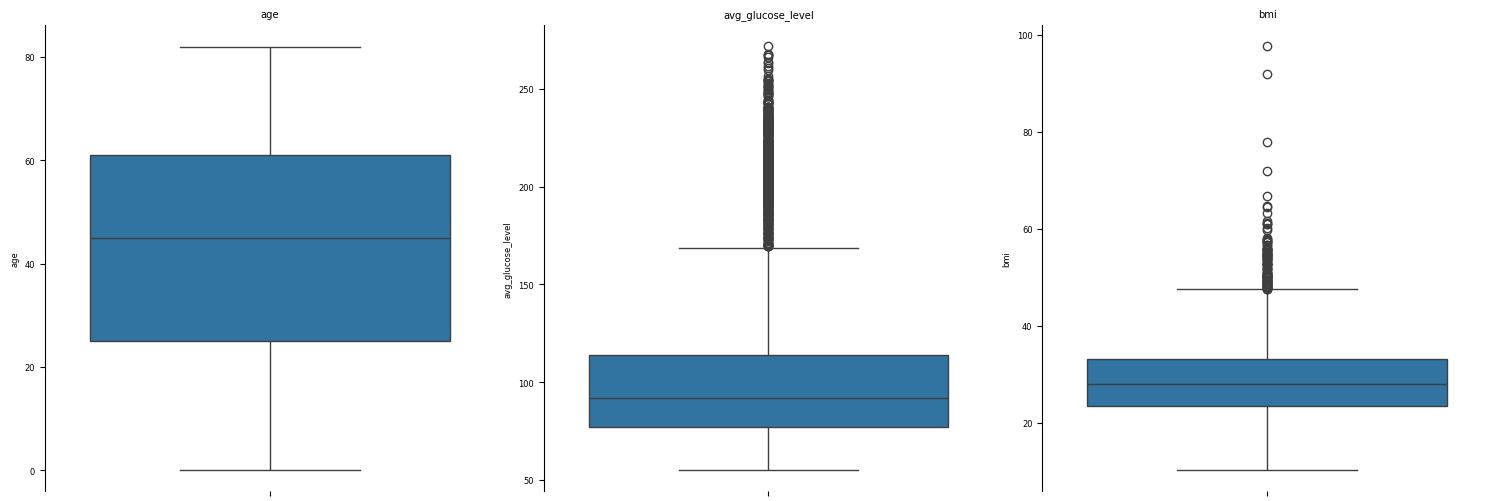

In [57]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
_, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df[col], ax=axes[i])
    title = ' '.join(c if c.isupper() and i > 0 else c for i, c in enumerate(col))
    axes[i].set(title=col, ylabel=col)
    [axes[i].spines[side].set_visible(False) for side in ['top', 'right', 'bottom']]

plt.tight_layout(); plt.show()

The boxplots reveal outliers in average glucose level and BMI features, but these likely represent genuine medical conditionss. 

**2.7  Splitting the Data**

In [58]:
X = df.drop(columns=["stroke"])
y = df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42, stratify=y)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (4087, 10)
y_train: (4087,)

Test set:
X_test: (1022, 10)
y_test: (1022,)


The data has been split into training (80%, 4087 samples) and test (20%, 1022 samples) sets using stratification on the 'stroke' variable to maintain the same proportion of stroke cases in both sets. This split is done before any EDA to prevent data leakage and ensure unbiased model evaluation.

**2.8  Imputation**

In [59]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level']
missing_bmi = X_train['bmi'].isna()

bmi_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ], remainder='passthrough')),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])
X_train_bmi = X_train[~missing_bmi][categorical_features + numerical_features]
bmi_pipeline.fit(X_train_bmi, X_train[~missing_bmi]['bmi'])
if missing_bmi.any():
    X_train.loc[missing_bmi, 'bmi'] = bmi_pipeline.predict(X_train[missing_bmi][categorical_features + numerical_features])

missing_bmi_test = X_test['bmi'].isna()

if missing_bmi_test.any():
    X_test.loc[missing_bmi_test, 'bmi'] = bmi_pipeline.predict(
        X_test[missing_bmi_test][categorical_features + numerical_features]
    )
    
X_train.loc[~missing_bmi].head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
845,Female,48.00,0,0,Yes,Private,Urban,69.21,33.10,never_smoked
3745,Female,29.00,0,0,No,Private,Urban,84.19,21.20,never_smoked
4184,Female,35.00,0,0,Yes,Private,Rural,119.40,22.90,never_smoked
3410,Male,38.00,0,0,Yes,Private,Rural,108.68,32.70,never_smoked
284,Male,14.00,0,0,No,Govt_job,Urban,82.34,31.60,Unknown


Random Forest imputation was chosen for BMI's missing values because it effectively handles all available features, capturing complex non-linear relationships in the data while offering better accuracy than simple median imputation. The model learns patterns from existing BMI values to predict missing ones by building decision trees based on combinations of the features. Looking at the table, the imputed BMI values (ranging from 21.20 to 33.10) appear reasonable. 

### 3. EXPLORATORY DATA ANALYSIS

**3.1  Statistical Summary**

In [60]:
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
X_train[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,"4,087.00","4,087.00","4,087.00"
mean,43.26,105.90,28.96
std,22.64,44.68,7.81
min,0.08,55.22,10.30
25%,25.00,77.45,23.70
50%,45.00,91.89,28.27
75%,61.00,114.03,33.10
max,82.00,271.74,97.60


This statistical summary tells us about the continous numerical variables in our stroke prediction dataset. Patients have an average age of approximately 43 years, with ages ranging widely from less than 1 year to 82 years, showing a diverse age distribution. Average glucose levels vary significantly, with a mean of 105.90 mg/dL and ranging from 55.22 to 271.74 mg/dL. BMI measurements have an average of 28.96 and values ranging from 10.30 to 97.60. The data shows considerable variation across all health indicators.

**3.2 Distribution of Variables**

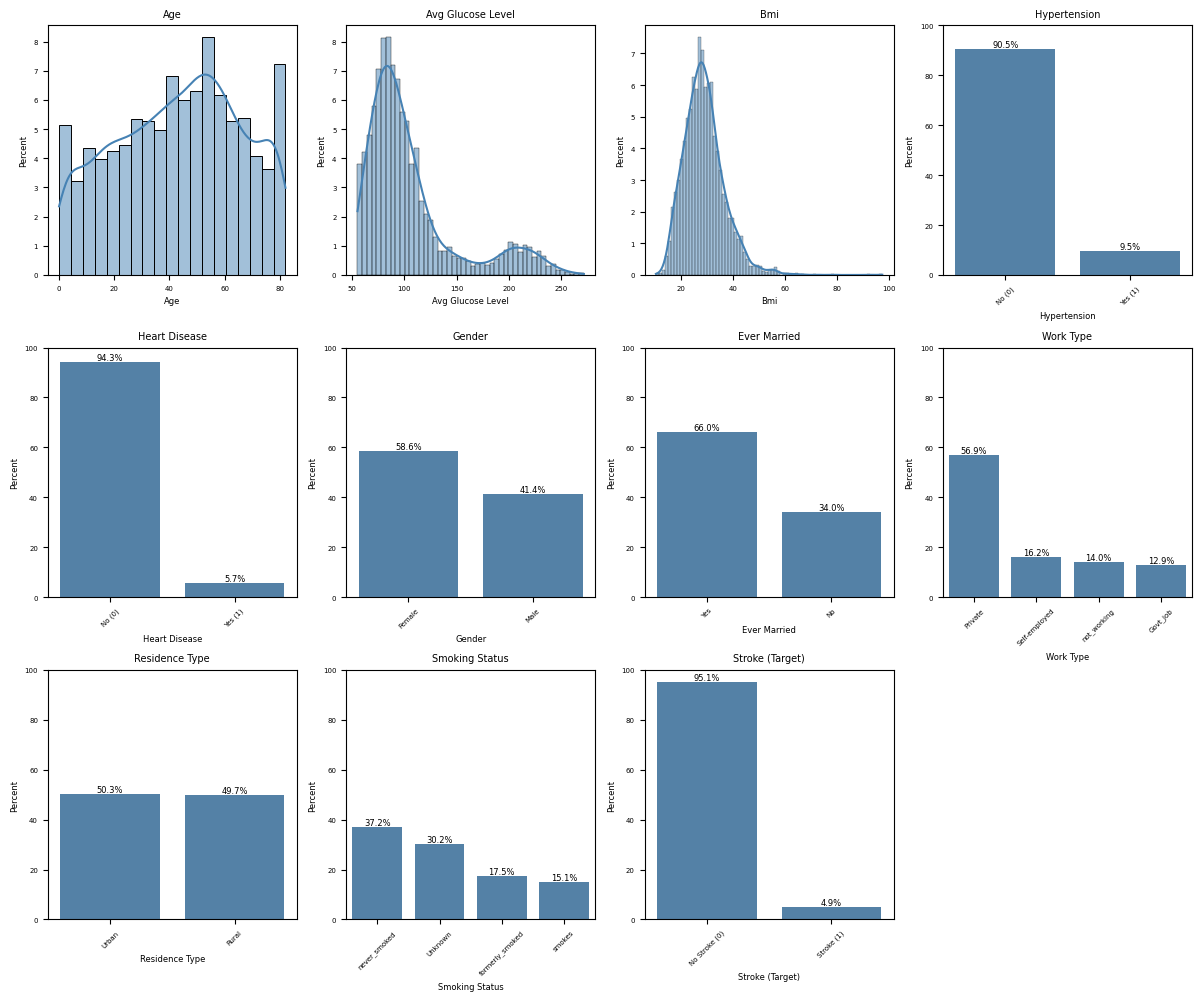

In [61]:
warnings.filterwarnings('ignore')
fig, axes = plt.subplots(3, 4, figsize=(12, 10))  
axes = axes.ravel()
plt.rcParams.update({'font.size': 6})  

binary_labels = {
    'hypertension': ['No (0)', 'Yes (1)'],
    'heart_disease': ['No (0)', 'Yes (1)'],
    'stroke': ['No Stroke (0)', 'Stroke (1)']  
}

continuous_vars = ['age', 'avg_glucose_level', 'bmi']
binary_vars = ['hypertension', 'heart_disease']
categorical_vars = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']  

for idx, var in enumerate(continuous_vars + binary_vars + categorical_vars):
    if var == 'stroke': 
        percentages = y_train.value_counts().sort_index() / len(y_train) * 100
        sns.barplot(x=['0', '1'], y=percentages.values, color='steelblue', ax=axes[idx])
        [axes[idx].text(i, p, f'{p:.1f}%', ha='center', va='bottom', fontsize=6) 
         for i, p in enumerate(percentages)]
        axes[idx].set_ylim(0, 100)
        axes[idx].set_xticklabels(binary_labels[var], rotation=45)
        title = 'Stroke (Target)'
    elif var in continuous_vars:
        sns.histplot(data=X_train, x=var, kde=True, 
                    color='steelblue', stat='percent', ax=axes[idx])
        title = ' '.join(var.split('_')).title()
    elif var in binary_vars:
        percentages = X_train[var].value_counts().sort_index() / len(X_train) * 100
        sns.barplot(x=['0', '1'], y=percentages.values, color='steelblue', ax=axes[idx])
        [axes[idx].text(i, p, f'{p:.1f}%', ha='center', va='bottom', fontsize=6) 
         for i, p in enumerate(percentages)]
        axes[idx].set_ylim(0, 100)
        axes[idx].set_xticklabels(binary_labels[var], rotation=45)
        title = ' '.join(var.split('_')).title()
    else:  
        percentages = X_train[var].value_counts() / len(X_train) * 100
        sns.barplot(x=percentages.index, y=percentages.values, color='steelblue', ax=axes[idx])
        [axes[idx].text(i, p, f'{p:.1f}%', ha='center', va='bottom', fontsize=6) 
         for i, p in enumerate(percentages)]
        axes[idx].set_ylim(0, 100)
        axes[idx].tick_params(axis='x', rotation=45)
        title = ' '.join(var.split('_')).title()

    axes[idx].set_title(title, fontsize=7)
    axes[idx].set_xlabel(title, fontsize=6)
    axes[idx].set_ylabel('Percent', fontsize=6)
    axes[idx].tick_params(axis='both', labelsize=5)


fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

* **Target**: The data shows a significant class imbalance in the target variable (stroke), with only 4.9% of cases having experienced a stroke (95.1% no stroke). Care will need to be taken here at the modelling stage. 
* **Features**: Age distribution is relatively uniform across middle-age ranges (45-65), while glucose levels show a right-skewed distribution. BMI follows a roughly normal distribution centered at 25-30. The dataset has more females (58.6%) than males (41.4%). There are more married individuals (66% vs 34%), and a predominance of private sector workers (57%). Most patients do not have hypertension (90.5% vs 9.5%) or heart disease (94.3% vs 5.7%). Smoking status reveals that most people never smoked (37.2%), followed by unknown (30.2%), formerly smoked (17.5%), and smokes (15.1%). Residence type is nearly evenly split between urban (50.3%) and rural (49.7%) areas.

**3.2.1 Class Imbalance**

In [62]:
neg_pos_ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Ratio of negative (no stroke) to positive (stroke) cases: {neg_pos_ratio:.2f}")
print("\nClass distribution:")
print(y_train.value_counts())

Ratio of negative (no stroke) to positive (stroke) cases: 19.54

Class distribution:
stroke
0    3888
1     199
Name: count, dtype: int64


The results indicate a significant class imbalance in our training dataset, with 3,888 non-stroke cases and only 199 stroke cases. This yields a ratio of approximately 19.5:1, meaning there are nearly 20 times more non-stroke instances than stroke instances. To address this imbalance during the machine learning stage, we will apply a class balance parameter to ensure the model doesn't become biased toward the majority class.

**3.3 Relationship between Variables and Target Variable**

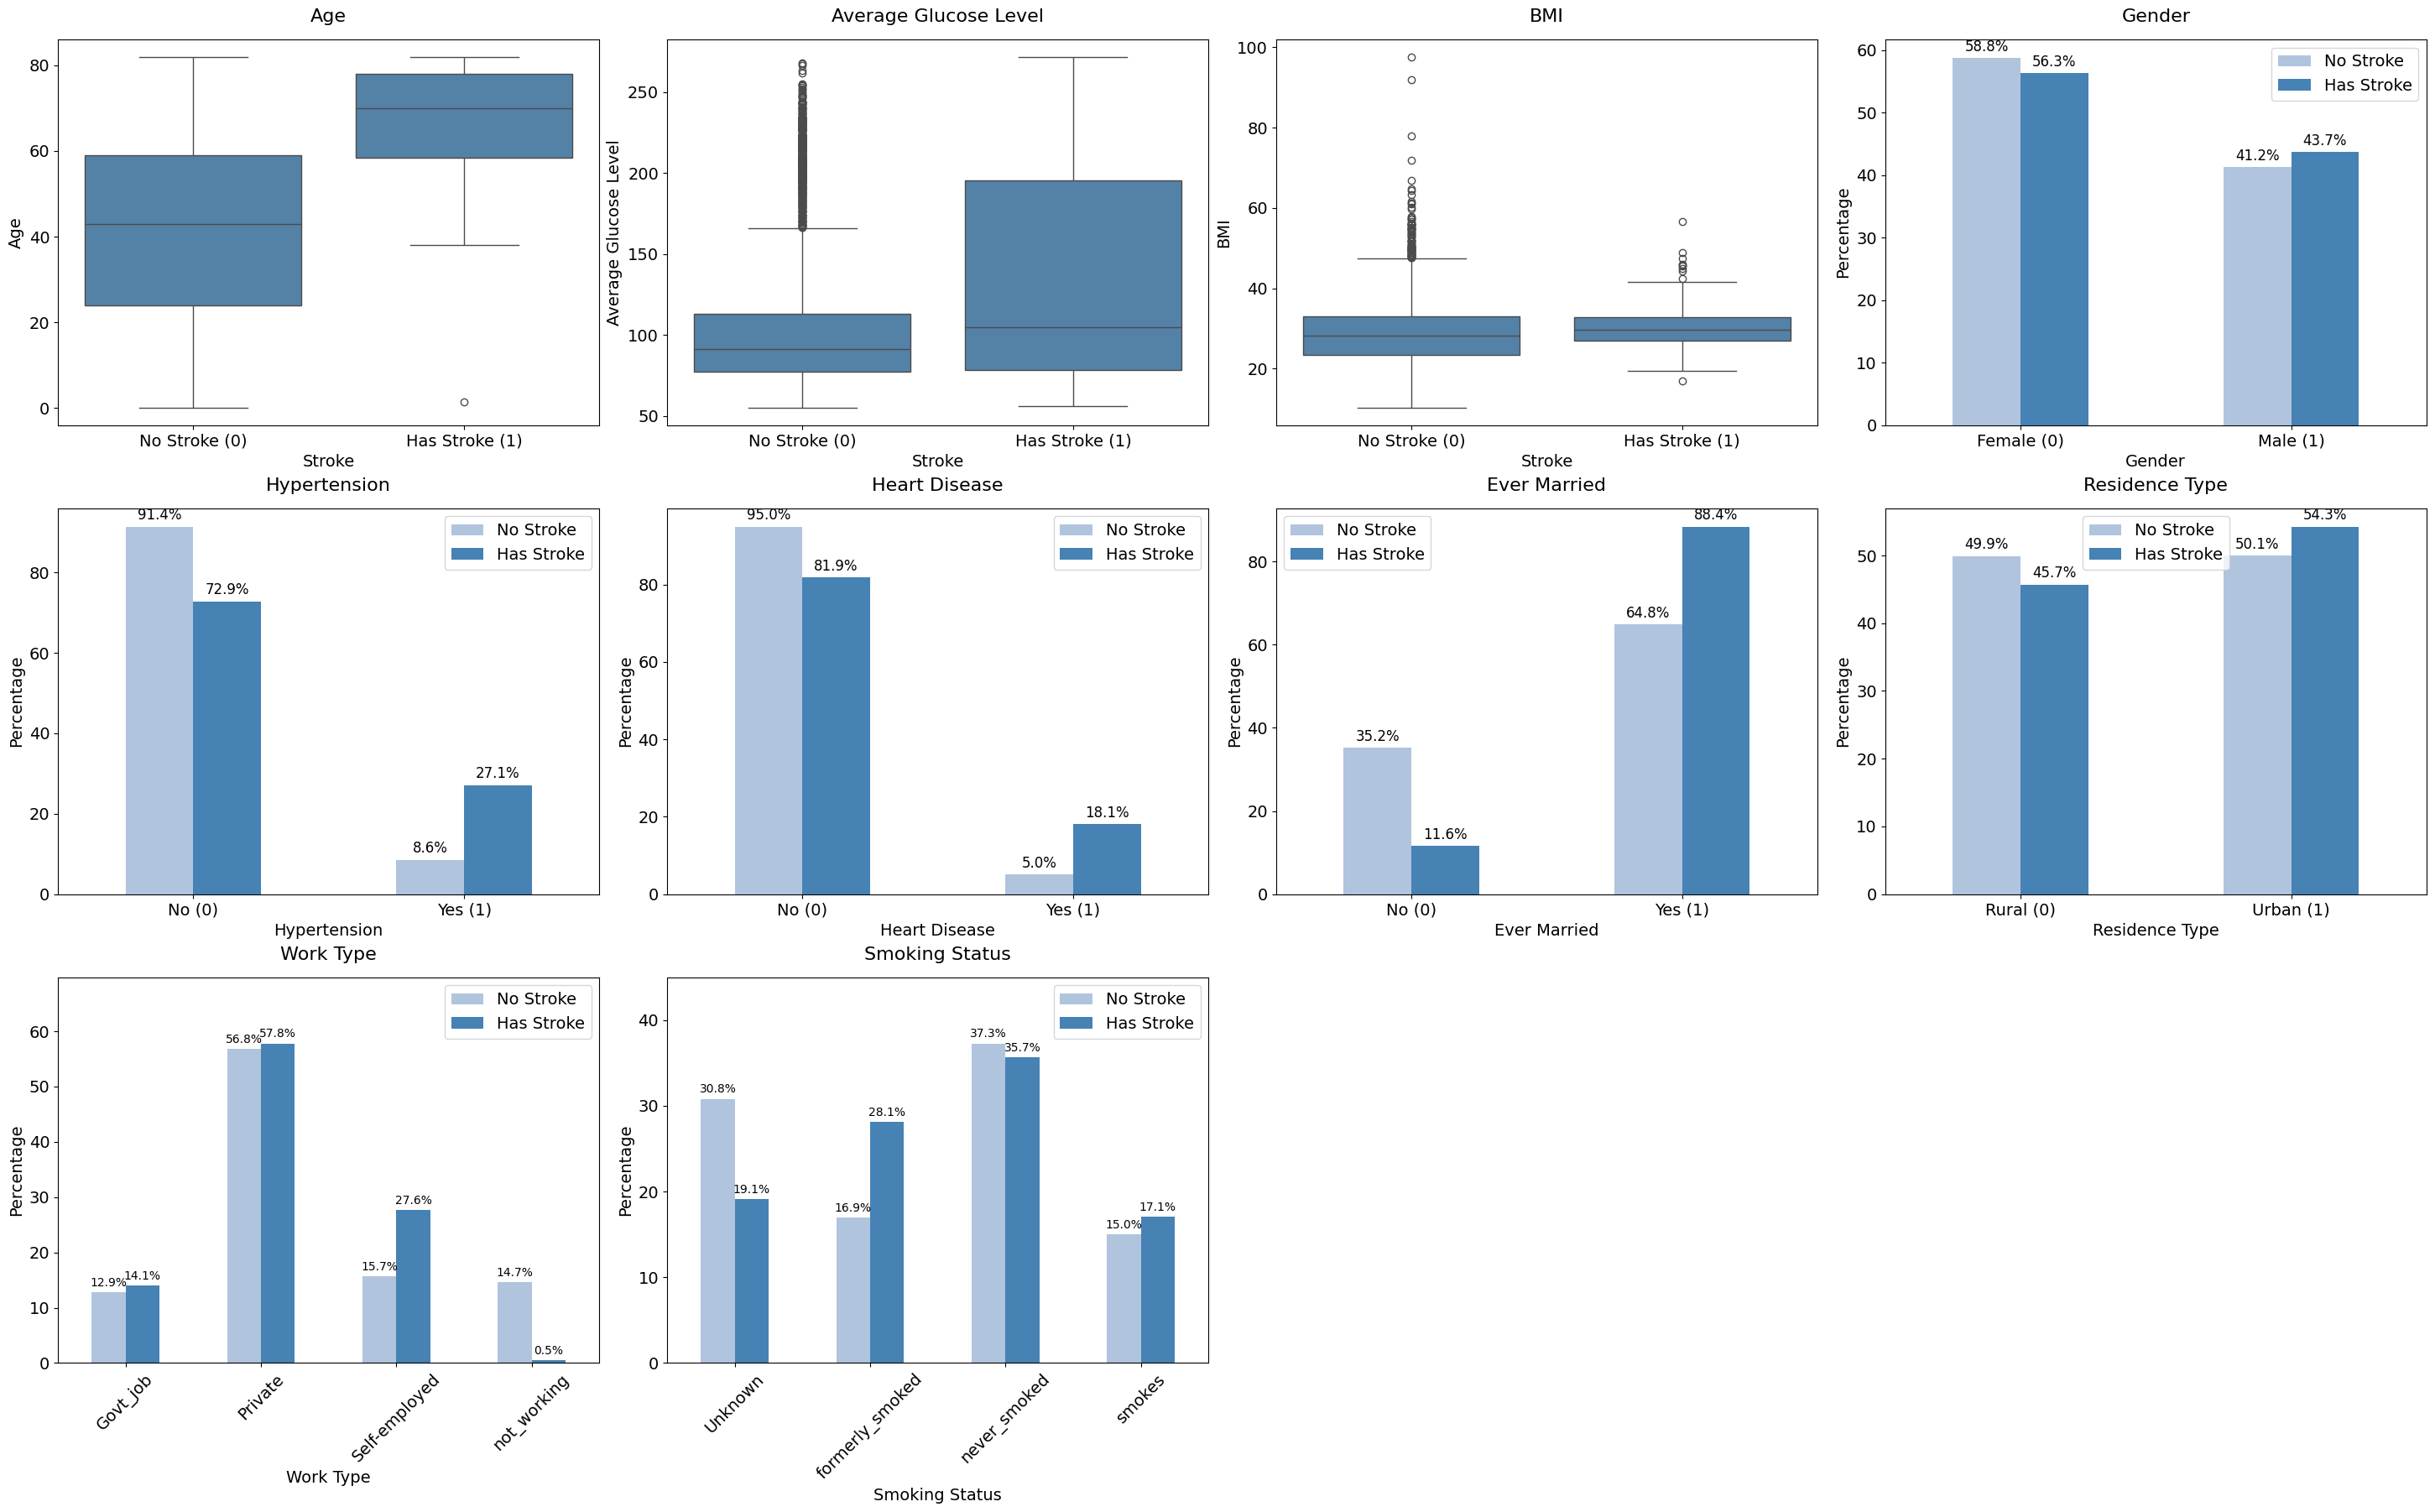

In [63]:
warnings.filterwarnings('ignore')
train_df = X_train.copy()
train_df['stroke'] = y_train

numerical_vars = ['age', 'avg_glucose_level', 'bmi']
binary_vars = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type']
categorical_vars = ['work_type', 'smoking_status']

formats = {
    'age': 'Age',
    'avg_glucose_level': 'Average Glucose Level',
    'bmi': 'BMI',
    'gender': ['Gender', ['Female (0)', 'Male (1)']],
    'hypertension': ['Hypertension', ['No (0)', 'Yes (1)']],
    'heart_disease': ['Heart Disease', ['No (0)', 'Yes (1)']],
    'ever_married': ['Ever Married', ['No (0)', 'Yes (1)']],
    'Residence_type': ['Residence Type', ['Rural (0)', 'Urban (1)']]
}

fig, axes = plt.subplots(3, 4, figsize=(29, 18))
axes = axes.ravel()

for idx, var in enumerate(numerical_vars + binary_vars + categorical_vars[:2]):  
    if idx < 3: 
        sns.boxplot(x='stroke', y=var, data=train_df, ax=axes[idx], 
                   color='steelblue', showmeans=False)
        axes[idx].set_ylabel(formats[var] if var in formats else var.replace('_', ' ').title(), fontsize=14)
        axes[idx].set_xticklabels(['No Stroke (0)', 'Has Stroke (1)'], fontsize=14)
    else:  
        cross_tab = pd.crosstab(train_df[var], train_df['stroke'])
        pct = cross_tab.div(cross_tab.sum(axis=0), axis=1) * 100
        pct.plot(kind='bar', ax=axes[idx], color=['lightsteelblue', 'steelblue'])
        
        label_size = 10 if var in ['work_type', 'smoking_status'] else 12
        
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f%%', fontsize=label_size, 
                              padding=3,  
                              label_type='edge') 
        
        axes[idx].legend(['No Stroke', 'Has Stroke'], fontsize=14)
        
        if var in formats:  
            axes[idx].set_xticklabels(formats[var][1], rotation=0, fontsize=14)
        else: 
            axes[idx].tick_params(axis='x', rotation=45)
            current_ymax = axes[idx].get_ylim()[1]
            axes[idx].set_ylim(0, current_ymax * 1.15) 
    
    if var in formats:
        title = formats[var][0] if isinstance(formats[var], list) else formats[var]
    else:
        title = var.replace('_', ' ').title()
    
    axes[idx].set_title(title, fontsize=16, pad=15)
    axes[idx].set_xlabel('Stroke' if idx < 3 else title, fontsize=14)
    axes[idx].tick_params(axis='both', labelsize=14)
    if idx >= 3: 
        axes[idx].set_ylabel('Percentage', fontsize=14)

fig.delaxes(axes[-1])  
fig.delaxes(axes[-2])
plt.tight_layout()
plt.show()

Stroke patients are significantly older (median ~65 vs 40 years) and showing higher glucose levels. Hypertension (27.1% vs 8.6%) and heart disease (18.1% vs 5%) are substantially more prevalent in stroke cases. Males have higher risk, married individuals represent a large proportion of cases (88.4%), and private sector employees show the highest representation (58%). Residence type shows minimal impact with near-even distribution between urban and rural areas. Smoking status presents notable patterns, particularly among former and never-smokers. 

**3.4 Correlation Matrix**

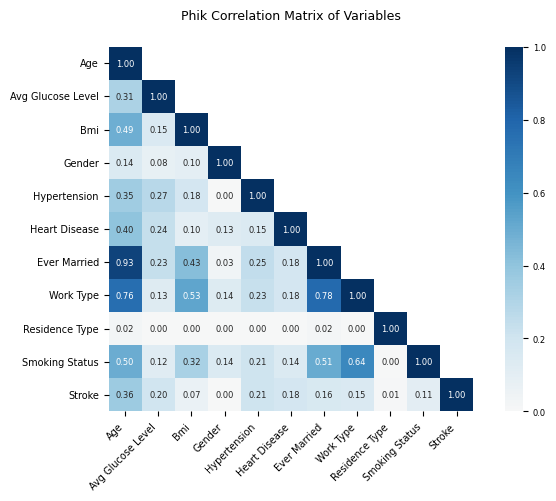

In [64]:
correlation_matrix = train_df[['age', 'avg_glucose_level', 'bmi', 'gender', 
                            'hypertension', 'heart_disease', 'ever_married',
                            'work_type', 'Residence_type', 'smoking_status', 
                            'stroke']].phik_matrix(interval_cols=['age', 'avg_glucose_level', 'bmi'])
mask = np.triu(np.ones_like(correlation_matrix), k=1)
formatted_labels = [col.replace('_', ' ').title() for col in correlation_matrix.columns]
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu',
            center=0,
            fmt='.2f',
            square=True,
            xticklabels=formatted_labels,
            yticklabels=formatted_labels)
plt.title('Phik Correlation Matrix of Variables', fontsize=9, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

The correlation matrix reveals that stroke risk has the strongest positive correlation with age (0.36), followed by hypertension (0.21) and average glucose level (0.20), while heart disease shows a moderate correlation (0.18). Age itself demonstrates strong correlations with several other variables, particularly ever married status (0.93) and work type (0.76). 

### 4. STATISTICAL INFERENCE

**4.1 Target Population**

The target population is patients at risk of stroke. 

**4.2 Statistical Hypotheses**

Based on the EDA, I have chosen to examine the relationship between the top 3 positively correlated independent variables and Stroke: 

<u>Hypothesis 1: Age</u> 

* **Null Hypothesis (H0):** There is no significant difference in mean age between stroke and non-stroke groups.
* **Alternative Hypothesis (H1):** There is no significant difference in mean age between stroke and non-stroke groups.

<u>Hypothesis 2: Hypertension</u> 

* **Null Hypothesis (H0):** There is no significant assosication between hypertension and stroke risk.
* **Alternative Hypothesis (H1):** There is a significant association between hypertension and stroke risk. 

<u>Hypothesis 3: Average Glucose Level</u> 

* **Null Hypothesis (H0):**  There is no significant difference in the mean glucose level between stroke and non-stroke groups. 
* **Alternative Hypothesis (H1):** There is a significant difference in mean glucose level between stroke and non-stroke groups.

**4.3 Statistical Testing**

The following analysis examines each hypothesis through statistical testing, including significance levels, appropriate test selection, and confidence interval construction.

**4.3.1 <u>Hypothesis 1: Age</u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Welch's t-test (tests for differences between means of two independent groups (stroke vs. non-stroke))

* **Assumptions:** (1) Does not require equal variances (to be verified below using Levene's test) and (2) requires data normality (to be verified below using Shapiro-Wilk test).

* **Testing Assumptions:**

<u>1. Unequal Variances: Levene's Test</u>

In [65]:
stat, p = stats.levene(train_df[train_df['stroke']==1]['age'], 
                      train_df[train_df['stroke']==0]['age'])
print(f"Levene: stat={stat:.4f}, p-value={p:.4f}")

Levene: stat=115.0425, p-value=0.0000


The Levene's test results (statistic=115.0425, p-value=0.0000) indicate that there is a significant difference in the variability of age between stroke and non-stroke patients. The extremely small p-value (<0.05) suggests that we reject the null hypothesis of equal variances and the assumption is met. 

<u>2. Data Normality: Shapiro-Wilk Test</u>

In [66]:
s1, p1 = stats.shapiro(train_df[train_df['stroke']==1]['age'])
s2, p2 = stats.shapiro(train_df[train_df['stroke']==0]['age'])
print(f"Shapiro: Str(p={p1:.4f}), NoStr(p={p2:.4f})")

Shapiro: Str(p=0.0000), NoStr(p=0.0000)


The test results tell us that the groups are not normally distributed due to the small p values but according to the Central Limit Theorem, with our large sample size (n=5110), the sampling distribution of means will approximate a normal distribution regardless of the underlying distribution, allowing us to proceed with parametric testing.

**Welch's t-test:**

In [67]:
t_stat, p_val = stats.ttest_ind(train_df[train_df['stroke']==1]['age'], train_df[train_df['stroke']==0]['age'], equal_var=False, alternative='two-sided')
print(f"Statistic={t_stat:.4f}, p-value={p_val:.4f}")

Statistic=28.0306, p-value=0.0000


The Welch's t-test results (statistic=28.0306, p-value=0.0000) tell us that there is a significant difference in mean age between stroke and non-stroke patients. The extremely small p-value (<0.05) leads us to reject the null hypothesis and accept the alternative hypothesis that there is a significant difference in mean age between the groups. The positive t-statistic suggests that stroke patients (group 1) tend to be significantly older than non-stroke patients (group 0). 

**Confidence Intervals**

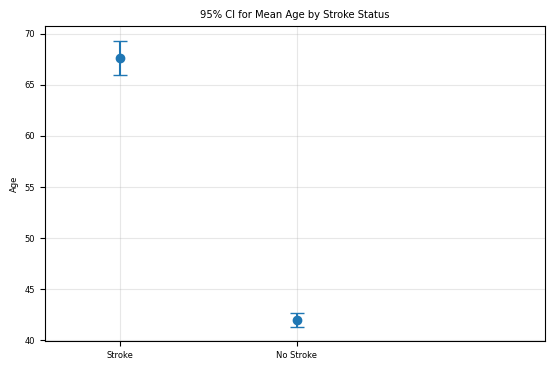

95% Confidence Intervals:
Stroke Patients: (66.00, 69.33)
Non-Stroke Patients: (40.35, 42.71)


In [68]:
age_stroke, age_no_stroke = train_df[train_df['stroke']==1]['age'], train_df[train_df['stroke']==0]['age']
mean_stroke, ci_stroke = np.mean(age_stroke), stats.t.ppf(0.975, len(age_stroke)-1) * stats.sem(age_stroke)
mean_no_stroke, ci_no_stroke = np.mean(age_no_stroke), stats.t.ppf(0.975, len(age_no_stroke)-1) * stats.sem(age_no_stroke)

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar([-0.14, 0.0013], [mean_stroke, mean_no_stroke], yerr=[ci_stroke, ci_no_stroke], fmt='o', capsize=5)
plt.xticks([-0.14, 0.0013], ['Stroke', 'No Stroke'])
plt.title('95% CI for Mean Age by Stroke Status')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7) 
plt.show()

print(f"95% Confidence Intervals:\nStroke Patients: ({mean_stroke-ci_stroke:.2f}, {mean_stroke+ci_stroke:.2f})\nNon-Stroke Patients: ({mean_no_stroke-ci_stroke:.2f}, {mean_no_stroke+ci_no_stroke:.2f})")

This interval plot tells us that we can be 95% confident that the true mean age for stroke patients falls between 66 and 69 years, while for non-stroke patients it falls between 40 and 43 years, showing a clear and significant age difference between the two groups.

**4.3.2 <u>Hypothesis 2: Hypertension</u>**

* **Significance level:** α = 0.05 (5%)

* **Test selection:** Chi-square Test of Independence (used to assess whether there is a significant association between hypertension status and stroke occurrence)

* **Assumptions:** (1) the variables are categorical (both hypertension status and stroke occurrence are binary: yes/no) (2) the observations are independent (yes), (3) all cells have the expected frequency of at least 5 (yes)

**Chi-square test of Independence**

In [69]:
contingency_table = pd.crosstab(train_df['hypertension'], train_df['stroke'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

Chi-square statistic: 74.0106
p-value: 0.0000


The Chi-square test results (statistic=74.0106, p-value=0.0000) indicate a highly significant association between hypertension and stroke occurrence. The extremely small p-value (<0.05) leads us to reject the null hypothesis and conclude that there is a strong statistical relationship between having hypertension and the likelihood of experiencing a stroke.

**Confidence Interval:** 

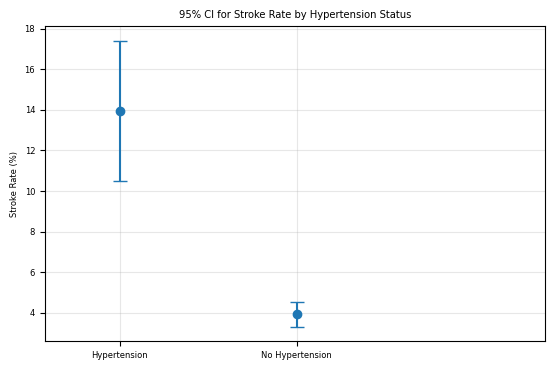

95% Confidence Intervals for Stroke Rate:
Hypertension Patients: (10.49%, 17.42%)
Non-Hypertension Patients: (3.29%, 4.54%)


In [70]:
hyper_stroke = train_df[(train_df['hypertension']==1) & (train_df['stroke']==1)].shape[0]
hyper_total = train_df[train_df['hypertension']==1].shape[0]
no_hyper_stroke = train_df[(train_df['hypertension']==0) & (train_df['stroke']==1)].shape[0]
no_hyper_total = train_df[train_df['hypertension']==0].shape[0]
prop_hyper = hyper_stroke/hyper_total
prop_no_hyper = no_hyper_stroke/no_hyper_total
ci_hyper = stats.t.ppf(0.975, hyper_total-1) * np.sqrt((prop_hyper * (1-prop_hyper))/hyper_total)
ci_no_hyper = stats.t.ppf(0.975, no_hyper_total-1) * np.sqrt((prop_no_hyper * (1-prop_no_hyper))/no_hyper_total)

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar([-0.14, 0.0013], [prop_hyper*100, prop_no_hyper*100], 
            yerr=[ci_hyper*100, ci_no_hyper*100], fmt='o', capsize=5)
plt.xticks([-0.14, 0.0013], ['Hypertension', 'No Hypertension'])
plt.title('95% CI for Stroke Rate by Hypertension Status')
plt.ylabel('Stroke Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()
print(f"95% Confidence Intervals for Stroke Rate:")
print(f"Hypertension Patients: ({(prop_hyper-ci_hyper)*100:.2f}%, {(prop_hyper+ci_hyper)*100:.2f}%)")
print(f"Non-Hypertension Patients: ({(prop_no_hyper-ci_no_hyper)*100:.2f}%, {(prop_no_hyper+ci_no_hyper)*100:.2f}%)")

This interval plot tells us that we can be 95% confident that the true stroke rate for patients with hypertension falls between 10.49% and 17.42%, while for patients without hypertension it falls between 3.29% and 4.54%, demonstrating that hypertension patients have a significantly higher stroke rate with no overlap between the confidence intervals.

**4.3.3 <u>Hypothesis 3: Average Glucose Level </u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Mann-Whitney U Test (compares whether the distribution of average glucose levels differs between individuals who had a stroke and those who did not)

* **Assumptions:** (1) continuous data (met as glucose level is continuous),(2) the distribution shape does not need to be normal (met as distribution is right-skewed as seen above in EDA), and (3) independent groups (met as each person either had a stroke or not). 

**Mann-Whitney U Test** 

In [71]:
stat, p = stats.mannwhitneyu(train_df[train_df['stroke']==1]['avg_glucose_level'],train_df[train_df['stroke']==0]['avg_glucose_level'], alternative='two-sided')
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p:.4f}")

Statistic: 463226.0000
p-value: 0.0000


The Mann-Whitney U test results (statistic=463226.0000, p-value=0.0000) indicate a highly significant difference in the distribution of average glucose levels between stroke and non-stroke patients. The extremely small p-value (<0.05) leads us to reject the null hypothesis and conclude that there is a significant difference in glucose levels between the two groups. 

**Confidence Intervals**

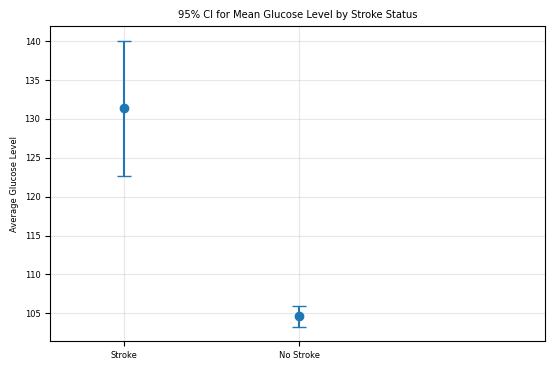

95% Confidence Intervals:
Stroke Patients: (122.70, 140.08)
Non-Stroke Patients: (103.23, 105.95)


In [72]:
glucose_stroke = train_df[train_df['stroke']==1]['avg_glucose_level']
glucose_no_stroke = train_df[train_df['stroke']==0]['avg_glucose_level']
mean_stroke, ci_stroke = np.mean(glucose_stroke), stats.t.ppf(0.975, len(glucose_stroke)-1) * stats.sem(glucose_stroke)
mean_no_stroke, ci_no_stroke = np.mean(glucose_no_stroke), stats.t.ppf(0.975, len(glucose_no_stroke)-1) * stats.sem(glucose_no_stroke)

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar([-0.14, 0.0013], [mean_stroke, mean_no_stroke], yerr=[ci_stroke, ci_no_stroke], fmt='o', capsize=5)
plt.xticks([-0.14, 0.0013], ['Stroke', 'No Stroke'])
plt.title('95% CI for Mean Glucose Level by Stroke Status')
plt.ylabel('Average Glucose Level')
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print(f"95% Confidence Intervals:")
print(f"Stroke Patients: ({mean_stroke-ci_stroke:.2f}, {mean_stroke+ci_stroke:.2f})")
print(f"Non-Stroke Patients: ({mean_no_stroke-ci_no_stroke:.2f}, {mean_no_stroke+ci_no_stroke:.2f})")

This interval plot tells us that we can be 95% confident that the true mean glucose level for stroke patients falls between 122.70 and 140.08 mg/dL, while for non-stroke patients it falls between 103.23 and 105.95 mg/dL, showing that stroke patients have significantly higher glucose levels with no overlap between the confidence intervals.

### 5. MACHINE LEARNING MODELS

**5.1 Model Selection**

In [73]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(verbosity=-1,random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

Next I train and evaluate the following models: (1) Logistic regression, (2) XGBoost (3) LightGBM and (4) Support Vector Machine (SVM). These four models were selected to allow us to compare different approaches and select the best performing model for stroke prediction. 

**5.2 Model Pipeline**

In [ ]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

preprocessor_with_scaling = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])
preprocessor_without_scaling = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('classifier', models['Logistic Regression'])
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('classifier', models['SVM'])
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('classifier', models['XGBoost'])
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('classifier', models['LightGBM'])
    ])
}

Here I have created two preprocessing pipelines: one with feature scaling for models sensitive to data scale (Logistic Regression and SVM), and one without scaling for tree-based models (XGBoost and LightGBM) and both pipelines handle categorical features through one-hot encoding. These pipelines are then combined with their respective models to create a standardised workflow that ensures consistent data preprocessing across model training. 

**5.3 Model Fitting**

**5.3.1 Baseline Model**

In [75]:
strategies = ['stratified', 'most_frequent', 'prior', 'uniform', 'constant']
dummy_results = []
for strategy in strategies:
    if strategy == 'constant':
        dummy_clf = DummyClassifier(strategy=strategy, random_state=42, constant=1)
    else:
        dummy_clf = DummyClassifier(strategy=strategy, random_state=42)
    
    dummy_clf.fit(X_train, y_train)
    y_pred_dummy = dummy_clf.predict(X_train)
    y_scores_dummy = dummy_clf.predict_proba(X_train)[:, 1]
    
    dummy_results.append({
        'Model': f'{strategy}',
        'Accuracy': accuracy_score(y_train, y_pred_dummy),
        'Precision': precision_score(y_train, y_pred_dummy, average='binary', zero_division=0),
        'Recall': recall_score(y_train, y_pred_dummy),
        'F1 Score': f1_score(y_train, y_pred_dummy, average='binary', zero_division=0),
        'ROC AUC': roc_auc_score(y_train, y_scores_dummy),
        'PR AUC': average_precision_score(y_train, y_scores_dummy)
    })
dummy_results_df = pd.DataFrame(dummy_results)
display(dummy_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,stratified,0.91,0.04,0.05,0.04,0.50,0.05
1,most_frequent,0.95,0.00,0.00,0.00,0.50,0.05
2,prior,0.95,0.00,0.00,0.00,0.50,0.05
3,uniform,0.50,0.05,0.51,0.09,0.50,0.05
4,constant,0.05,0.05,1.00,0.09,0.50,0.05


This baseline model shows us the bare minimum performance we should expect from our real models below, with a PR AUC of 0.05 setting the minimum threshold that our actual models must exceed. 

**5.3.2 Default Model Fitting**

In [76]:
warnings.filterwarnings('ignore')
results = []
for name, pipeline in pipelines.items():  
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_train)  
    y_scores = pipeline.predict_proba(X_train)[:, 1] 
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_train, y_pred),  
        'Precision': precision_score(y_train, y_pred, average='binary', zero_division=0),  
        'Recall': recall_score(y_train, y_pred), 
        'F1 Score': f1_score(y_train, y_pred, average='binary', zero_division=0),  
        'ROC AUC': roc_auc_score(y_train, y_scores),  
        'PR AUC': average_precision_score(y_train, y_scores)  
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Logistic Regression,0.95,0.00,0.00,0.00,0.85,0.19
1,SVM,0.95,0.00,0.00,0.00,0.94,0.73
2,XGBoost,1.00,1.00,0.94,0.97,1.00,1.00
3,LightGBM,0.99,1.00,0.84,0.92,1.00,1.00


The default model fitting shows varying performance across our four models. Logistic Regression and SVM achieve high accuracy (0.95) and reasonable ROC AUC scores (0.85 and 0.94), their precision, recall, and F1 scores of 0.00 indicate they're struggling with the imbalanced dataset. In contrast, the tree-based models (XGBoost and LightGBM) demonstrate superior performance across all metrics, with XGBoost achieving perfect or near-perfect scores (PR AUC = 1.00, F1 Score = 0.97) and LightGBM showing similarly strong results (PR AUC = 1.00, F1 Score = 0.92).

**5.3.2.1 Classification Report**

In [77]:
for name, pipeline in pipelines.items():
    print(f"\nClassification Report for {name}:")
    print("="*50)
    y_pred = pipeline.predict(X_train)
    report = classification_report(y_train, y_pred, target_names=['No Stroke', 'Stroke'],digits=2)
    print(report)


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.98      3888
      Stroke       0.00      0.00      0.00       199

    accuracy                           0.95      4087
   macro avg       0.48      0.50      0.49      4087
weighted avg       0.90      0.95      0.93      4087


Classification Report for SVM:
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.98      3888
      Stroke       0.00      0.00      0.00       199

    accuracy                           0.95      4087
   macro avg       0.48      0.50      0.49      4087
weighted avg       0.90      0.95      0.93      4087


Classification Report for XGBoost:
              precision    recall  f1-score   support

   No Stroke       1.00      1.00      1.00      3888
      Stroke       1.00      0.94      0.97       199

    accuracy                           1.00      4087
   macro avg

**5.3.2.2 Comparison of PR AUC Model Performance**

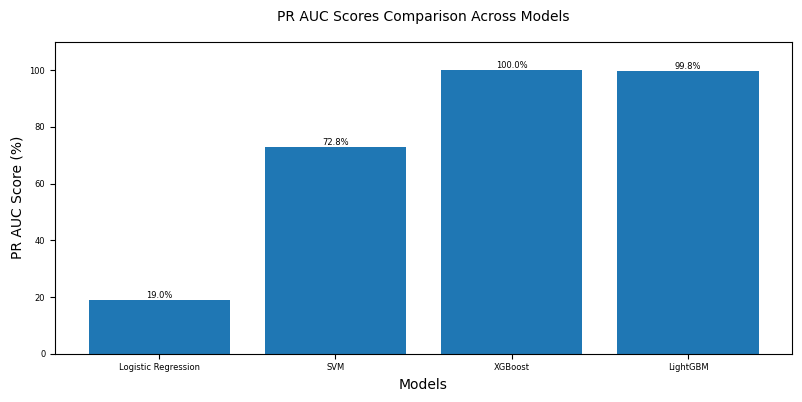

In [78]:
plt.figure(figsize=(8, 4))
models = results_df['Model']
pr_auc_scores = results_df['PR AUC']
pr_auc_percentages = pr_auc_scores * 100
bars = plt.bar(models, pr_auc_percentages)
plt.title('PR AUC Scores Comparison Across Models', fontsize=10, pad=15)
plt.xlabel('Models', fontsize=10)
plt.ylabel('PR AUC Score (%)', fontsize=10)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')
plt.ylim(0, max(pr_auc_percentages) * 1.1)
plt.tight_layout()
plt.show()

The PR AUC scores comparison reveals a stark performance difference between traditional and tree-based models. While Logistic Regression (18%) and SVM (25%) are on the lower end, XGBoost and LightGBM achieve near-perfect scores. These exceptionally high scores for the tree-based models, suggest potential overfitting to the training data. A confusion matrix analysis is necessary to verify if these models are truly performing this well (below).

**5.3.2.3 Confusion Matrices**

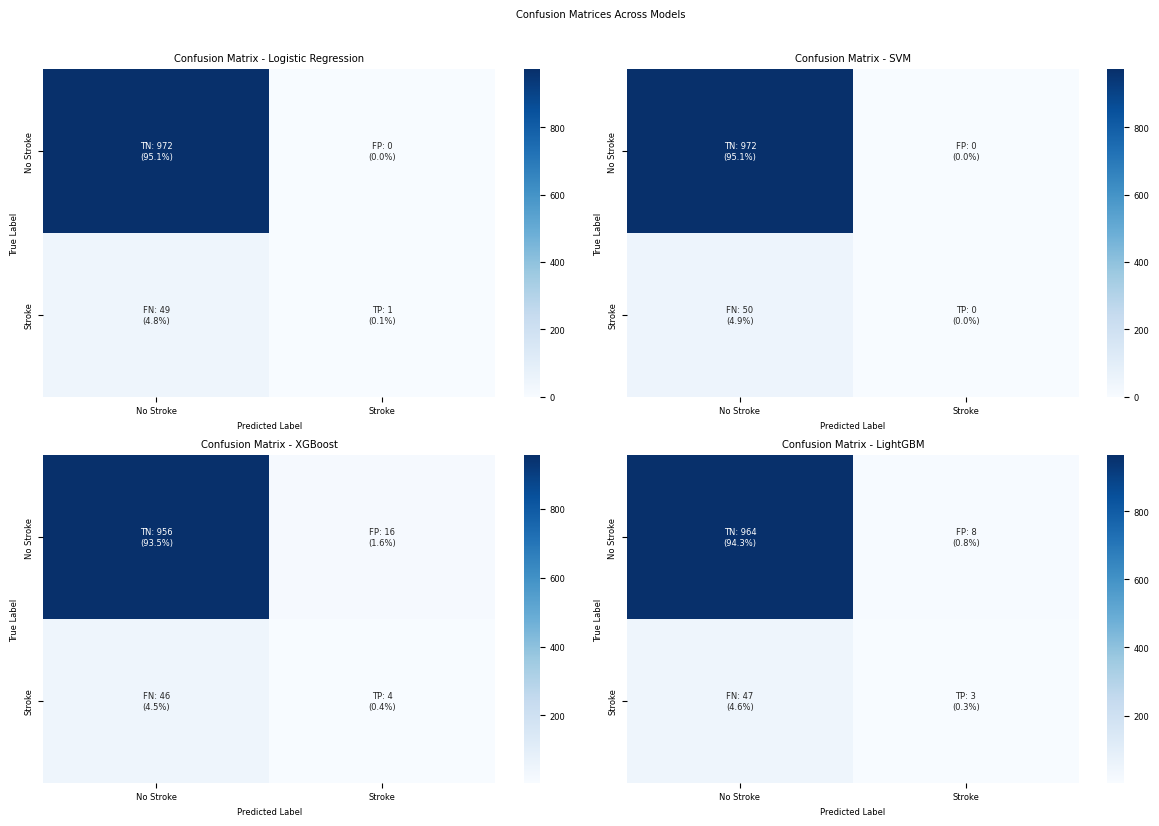

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for idx, (name, pipeline) in enumerate(pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    total = np.sum(cm)
    cm_percentages = cm / total * 100
    labels = np.array([
        [f'TN: {cm[0,0]}\n({cm_percentages[0,0]:.1f}%)', f'FP: {cm[0,1]}\n({cm_percentages[0,1]:.1f}%)'],
        [f'FN: {cm[1,0]}\n({cm_percentages[1,0]:.1f}%)', f'TP: {cm[1,1]}\n({cm_percentages[1,1]:.1f}%)']
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                ax=axes[idx])
    
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices Across Models', y=1.02)
plt.tight_layout()
plt.show()

Logistic Regression and SVM show similar patterns, correctly identifying most non-stroke cases (TN: 972, 95.1%) but struggling with stroke predictions (TP: 1 and 0 respectively), indicating poor sensitivity to the minority class. XGBoost and LightGBM perform slightly better at identifying stroke cases (TP: 4 and 3 respectively), but still show high false negative rates (FN: 46 and 47). While all models excel at identifying non-stroke cases, their low true positive rates suggest they're biased toward the majority class, which is problematic for a medical diagnosis application where missing stroke cases (false negatives) could have serious consequences.

**5.4 Hyperparameter Tuning**

Given the confusion matrices reveal poor stroke detection expecially in the tree based models, I will now perform hyperparameter tuning to enhance model sensitivity to stroke cases. Through iterative testing of various parameter combinations, I aim to optimise each model's ability to identify true stroke cases while maintaining good overall performance. 

In [80]:
models_default_tuned = results_df.copy()
models_default_tuned.columns = ['Model'] + [f'Default {col}' for col in results_df.columns[1:]]
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': ['balanced', {0:1, 1:10}, {0:1, 1:20}]
    },
    'SVM': {
        'classifier__C': [1.0, 2.0, 5.0],
        'classifier__kernel': ['rbf', 'linear'],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__class_weight': ['balanced', {0:1, 1:10}]
    },
    'XGBoost': {
        'classifier__scale_pos_weight': [1, 10, 20],
        'classifier__max_depth': [3, 4, 5],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__n_estimators': [100, 200]
    },
    'LightGBM': {
        'classifier__scale_pos_weight': [1, 10, 20],
        'classifier__num_leaves': [31, 63],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__n_estimators': [100, 200]
    }
}
scoring = {metric: metric if metric != 'pr_auc' else 'average_precision' 
          for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = []
for name, pipeline in pipelines.items():
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=skf, n_iter=20, 
                              scoring=scoring, refit='pr_auc', random_state=42).fit(X_train, y_train)
    tuned_results.append({
        'Model': name,
        'Tuned Accuracy': search.cv_results_['mean_test_accuracy'][search.best_index_],
        'Tuned Precision': search.cv_results_['mean_test_precision'][search.best_index_],
        'Tuned Recall': search.cv_results_['mean_test_recall'][search.best_index_],
        'Tuned F1 Score': search.cv_results_['mean_test_f1'][search.best_index_],
        'Tuned ROC AUC': search.cv_results_['mean_test_roc_auc'][search.best_index_],
        'Tuned PR AUC': search.cv_results_['mean_test_pr_auc'][search.best_index_]
    })
    print(f"\n{name}: {search.best_params_}")
final_comparison = pd.merge(models_default_tuned, pd.DataFrame(tuned_results), on='Model')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC']
improvements = pd.DataFrame({'Model': final_comparison['Model']})

for metric in metrics:
    improvements[f'{metric} Improvement'] = (
        final_comparison[f'Tuned {metric}'] - final_comparison[f'Default {metric}']
    ).round(3)

print("\nModel Performance Comparison (Default vs Tuned):")
display(final_comparison)
print("\nImprovements after tuning:")
display(improvements)


Logistic Regression: {'classifier__solver': 'saga', 'classifier__penalty': 'l1', 'classifier__class_weight': 'balanced', 'classifier__C': 1.0}

SVM: {'classifier__kernel': 'linear', 'classifier__gamma': 'scale', 'classifier__class_weight': 'balanced', 'classifier__C': 1.0}

XGBoost: {'classifier__scale_pos_weight': 1, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}

LightGBM: {'classifier__scale_pos_weight': 20, 'classifier__num_leaves': 31, 'classifier__n_estimators': 100, 'classifier__learning_rate': 0.01}

Model Performance Comparison (Default vs Tuned):


,Model,Default Accuracy,Default Precision,Default Recall,Default F1 Score,Default ROC AUC,Default PR AUC,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1 Score,Tuned ROC AUC,Tuned PR AUC
0,Logistic Regression,0.95,0.00,0.00,0.00,0.85,0.19,0.74,0.14,0.84,0.24,0.84,0.19
1,SVM,0.95,0.00,0.00,0.00,0.94,0.73,0.73,0.13,0.82,0.23,0.84,0.19
2,XGBoost,1.00,1.00,0.94,0.97,1.00,1.00,0.95,0.00,0.00,0.00,0.83,0.17
3,LightGBM,0.99,1.00,0.84,0.92,1.00,1.00,0.90,0.18,0.28,0.22,0.82,0.17



Improvements after tuning:


,Model,Accuracy Improvement,Precision Improvement,Recall Improvement,F1 Score Improvement,ROC AUC Improvement,PR AUC Improvement
0,Logistic Regression,-0.21,0.14,0.84,0.24,-0.01,0.01
1,SVM,-0.23,0.13,0.82,0.23,-0.10,-0.54
2,XGBoost,-0.05,-1.00,-0.94,-0.97,-0.17,-0.82
3,LightGBM,-0.09,-0.82,-0.56,-0.70,-0.18,-0.83


On the one hand, the default tree-based models (XGBoost and LightGBM) showed perfect or near-perfect scores initially with a high number of false negatives their tuned versions demonstrate lower performance. Conversely, Logistic Regression and SVM show improvements in precision and recall after tuning, particularly in recall (0.84 and 0.82 improvements respectively), though with slight decreases in accuracy.

**5.4.1 Confusion Matrices**

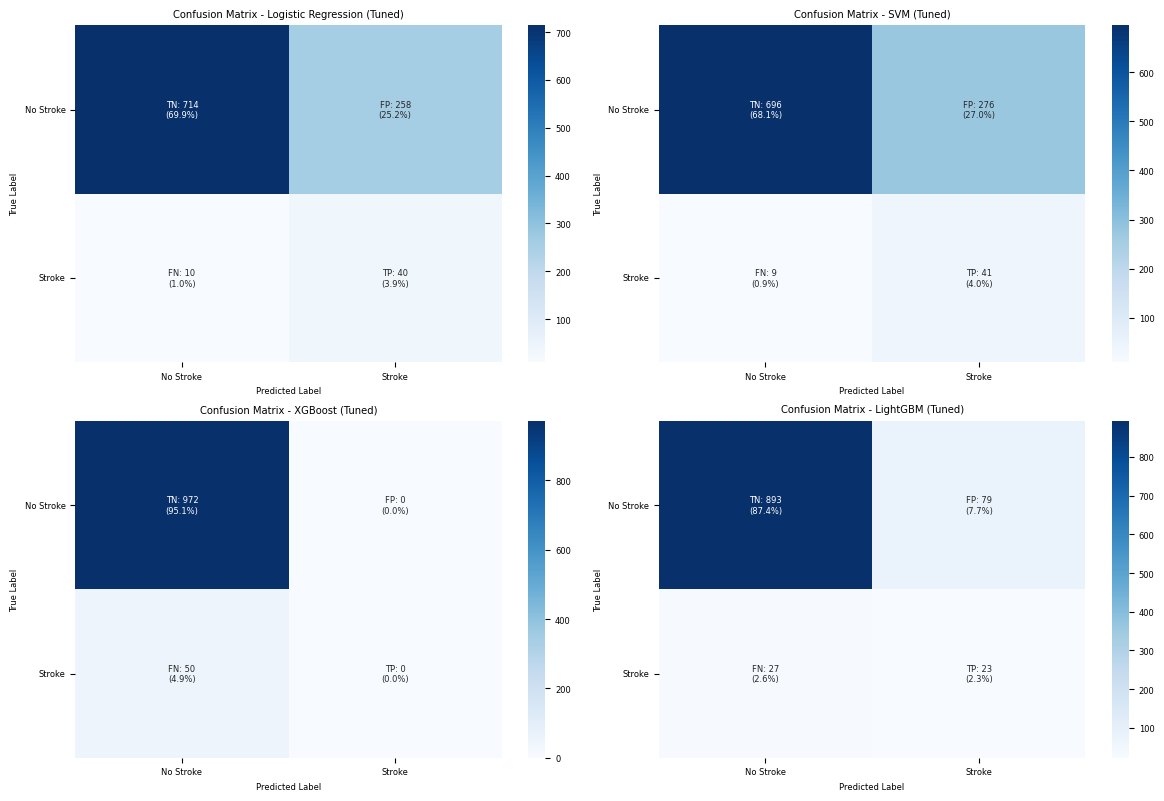

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for idx, (name, pipeline) in enumerate(pipelines.items()):
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=skf, n_iter=20, 
                              scoring=scoring, refit='pr_auc', random_state=42).fit(X_train, y_train)
    y_pred_tuned = search.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_tuned)
    total = np.sum(cm)
    cm_percentages = cm / total * 100
    labels = np.array([
        [f'TN: {cm[0,0]}\n({cm_percentages[0,0]:.1f}%)', f'FP: {cm[0,1]}\n({cm_percentages[0,1]:.1f}%)'],
        [f'FN: {cm[1,0]}\n({cm_percentages[1,0]:.1f}%)', f'TP: {cm[1,1]}\n({cm_percentages[1,1]:.1f}%)']
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name} (Tuned)')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['No Stroke', 'Stroke'])
    axes[idx].set_yticklabels(['No Stroke', 'Stroke'], rotation=0)

plt.tight_layout()
plt.show()

Logistic Regression and SVM show dramatically improved stroke detection, now identifying around 40 true stroke cases each (up from 1 and 0 respectively), but at the cost of many false positives (258 and 276) and reduced true negative rates (dropping from 95% to around 70%). The tree-based models show contrasting patterns: XGBoost maintains high accuracy for non-stroke cases (TN: 972, 95.1%) but fails to identify any stroke cases, while LightGBM achieves the most balanced performance, successfully identifying 23 stroke cases while maintaining good non-stroke detection (TN: 893, 87.4%).

**5.5 Model Ensembling**

Applying the voting classifier to both default and tuned models allows us to compare ensemble performance across both versions and determine if combining models effectively balances stroke detection with false positive rates. 

In [90]:
models = {
    'Default': pipelines, 
    'Tuned': {
        'Logistic Regression': Pipeline([
            ('preprocessor', preprocessor_with_scaling),
            ('classifier', LogisticRegression(solver='saga', penalty='l1', class_weight='balanced', C=1.0, random_state=42))
        ]),
        'SVM': Pipeline([
            ('preprocessor', preprocessor_with_scaling),
            ('classifier', SVC(kernel='linear', gamma='scale', class_weight='balanced', C=1.0, probability=True, random_state=42))
        ]),
        'XGBoost': Pipeline([
            ('preprocessor', preprocessor_without_scaling),
            ('classifier', XGBClassifier(scale_pos_weight=1, n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42))
        ]),
        'LightGBM': Pipeline([
            ('preprocessor', preprocessor_without_scaling),
            ('classifier', LGBMClassifier(scale_pos_weight=20, num_leaves=31, n_estimators=100, learning_rate=0.01, random_state=42))
        ])
    }
}
ensemble_results = []
for model_type in ['Default', 'Tuned']:
    for name, model in models[model_type].items():
        cv_results = cross_validate(model, X_train, y_train, scoring=scoring, cv=skf)
        ensemble_results.append({
            'Model': f"{name}_{model_type}",
            **{metric: cv_results[f'test_{metric}'].mean() for metric in scoring.keys()}
        })
    
    for r in range(2, len(models[model_type]) + 1):
        for combo in combinations(models[model_type].keys(), r):
            voter = VotingClassifier(
                estimators=[(name, models[model_type][name]) for name in combo],
                voting='soft'
            )
            cv_results = cross_validate(voter, X_train, y_train, scoring=scoring, cv=skf)
            ensemble_results.append({
                'Model': f"Voting_{model_type}_{'+'.join(combo)}",
                **{metric: cv_results[f'test_{metric}'].mean() for metric in scoring.keys()}
            })
ensemble_results_df = pd.DataFrame(ensemble_results).round(2)
display(ensemble_results_df.sort_values('pr_auc', ascending=False))

,Model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression_Default,0.95,0.00,0.00,0.00,0.84,0.19
16,SVM_Tuned,0.73,0.13,0.82,0.23,0.84,0.19
28,Voting_Tuned_SVM+XGBoost+LightGBM,0.95,0.00,0.00,0.00,0.84,0.19
26,Voting_Tuned_Logistic Regression+SVM+LightGBM,0.91,0.20,0.27,0.23,0.84,0.19
25,Voting_Tuned_Logistic Regression+SVM+XGBoost,0.95,0.00,0.00,0.00,0.84,0.19
22,Voting_Tuned_SVM+XGBoost,0.95,0.00,0.00,0.00,0.84,0.19
20,Voting_Tuned_Logistic Regression+XGBoost,0.92,0.22,0.21,0.21,0.84,0.19
19,Voting_Tuned_Logistic Regression+SVM,0.90,0.18,0.28,0.22,0.84,0.19
15,Logistic Regression_Tuned,0.74,0.14,0.84,0.24,0.84,0.19
29,Voting_Tuned_Logistic Regression+SVM+XGBoost+L...,0.95,0.11,0.01,0.02,0.84,0.19


The tuned Logistic Regression emerges as the optimal choice, achieving the highest recall (0.84). Some voting ensembles show higher accuracy but sacrifice stroke detection capability. The tuned Logistic Regression's balance of performance metrics, combined with its interpretability for feature importance purposes makes it the most suitable model for stroke prediction.

**5.6 Model Performance**

In [83]:
tuned_lr = Pipeline([
    ('preprocessor', preprocessor_with_scaling),
    ('classifier', LogisticRegression(
        solver='saga', 
        penalty='l1', 
        class_weight='balanced',
        C=1.0,
        random_state=42
    ))
])
tuned_lr.fit(X_train, y_train)
y_pred = tuned_lr.predict(X_test)
y_scores = tuned_lr.predict_proba(X_test)[:, 1]
test_results = {
    'Model': 'Tuned Logistic Regression (Test)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred, average='binary', zero_division=0),
    'ROC AUC': roc_auc_score(y_test, y_scores),
    'PR AUC': average_precision_score(y_test, y_scores)
}
display(pd.DataFrame([test_results]))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Tuned Logistic Regression (Test),0.74,0.13,0.80,0.23,0.84,0.26


The tuned Logistic Regression model demonstrates strong generalisation on unseen test data, maintaining key performance metrics (accuracy: 0.74, recall: 0.80) and showing improved PR AUC (0.26). 

**5.7 Classification Report**

In [84]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



The classification report reveals the model's performance across stroke and non-stroke predictions, highlighting a significant class imbalance challenge. For the majority non-stroke class (972 cases), the model performs exceptionally well with high precision (0.95), recall (0.99), and F1-score (0.97). However, for the minority stroke class (50 cases), performance is considerably weaker with low precision (0.27), very low recall (0.06), and poor F1-score (0.10). 

**5.8 Confusion Matrices**

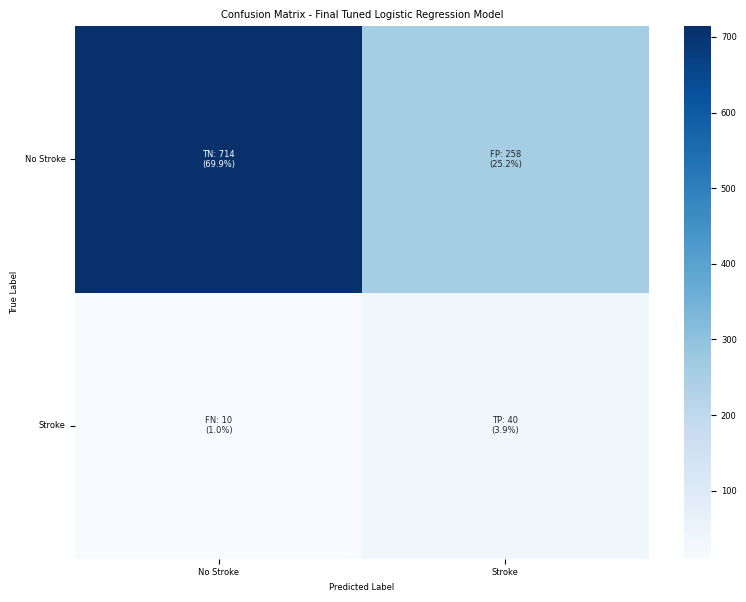

In [85]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
total = np.sum(cm)
cm_percentages = cm / total * 100
labels = np.array([
    [f'TN: {cm[0,0]}\n({cm_percentages[0,0]:.1f}%)', f'FP: {cm[0,1]}\n({cm_percentages[0,1]:.1f}%)'],
    [f'FN: {cm[1,0]}\n({cm_percentages[1,0]:.1f}%)', f'TP: {cm[1,1]}\n({cm_percentages[1,1]:.1f}%)']
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.title('Confusion Matrix - Final Tuned Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['No Stroke', 'Stroke'])
plt.yticks([0.5, 1.5], ['No Stroke', 'Stroke'], rotation=0)
plt.tight_layout()
plt.show()

The confusion matrix reinforces our classification report findings: while the model excels at identifying non-stroke cases (964 true negatives, 94.3%), it struggles significantly with stroke detection, identifying only 3 true positives (0.3%) and missing 47 stroke cases (4.6%). This clearly highlights the ongoing challenge of class imbalance. Possible solutions include collecting more stroke cases to balance the dataset or generating synthetic stroke cases. 

**5.9 Feature Importance Analysis**

**5.9.1 SHAP**

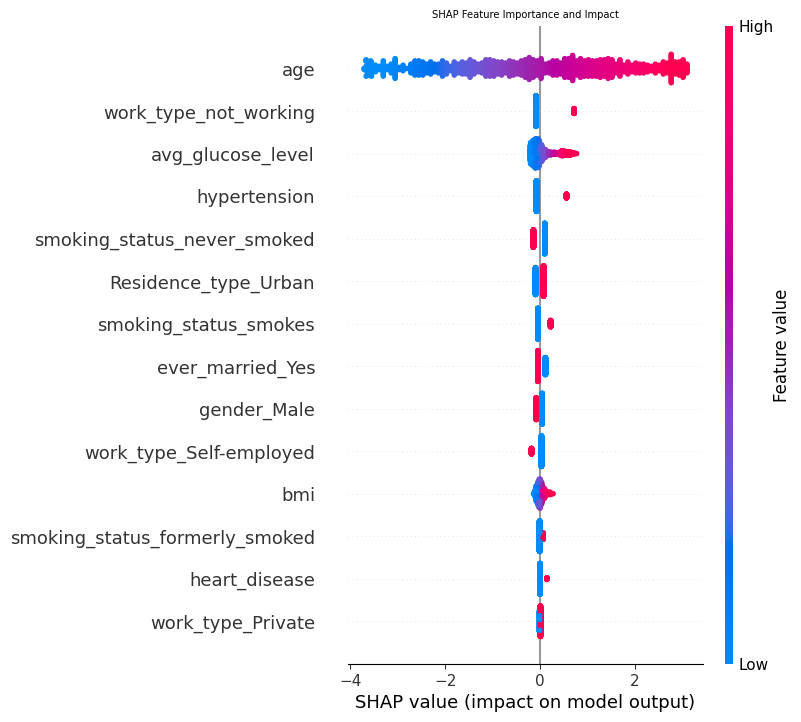

In [86]:

X_test_transformed = tuned_lr.named_steps['preprocessor'].transform(X_test)

explainer = shap.LinearExplainer(
    tuned_lr.named_steps['classifier'],
    X_test_transformed,
    feature_perturbation="interventional" 
)
shap_values = explainer.shap_values(X_test_transformed)

cat_features = tuned_lr.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out()
feature_names = np.concatenate([numerical_features, cat_features])

shap.summary_plot(shap_values, X_test_transformed,
                 feature_names=feature_names,
                 show=False)
plt.title("SHAP Feature Importance and Impact")
plt.show()

SHAP values reveal the direct impact of features on individual predictions. The SHAP value plot reveals that age is the dominant predictor of stroke risk. Health-related features like employment status (not working), hypertension, and smoking status follow in importance, while urban residence , glucose level and BMI show moderate influence. Demographic factors like gender and employment type (Private) have smaller effects, with heart disease showing surprisingly modest impact, possibly due to correlations with other features.

**5.9.2 Permutation Importance**

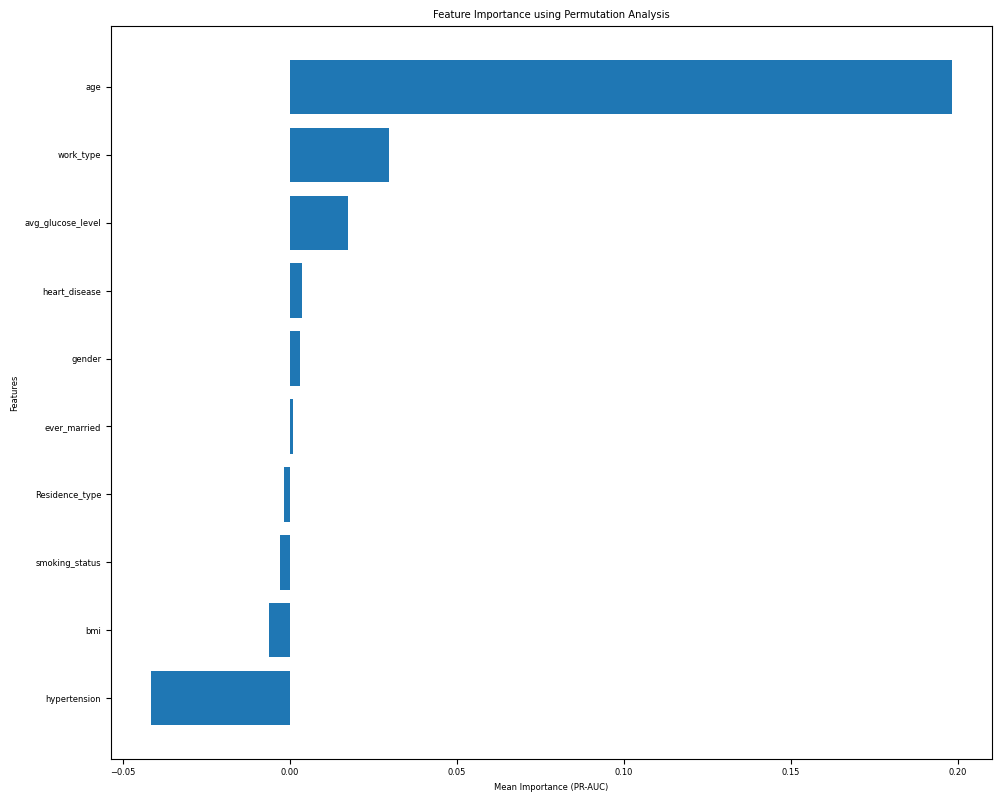

In [87]:
perm_importance = permutation_importance(
    tuned_lr,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='average_precision'
)
feature_names = X_test.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean[:len(feature_names)]
})
importance_df = importance_df.sort_values('Importance', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(range(len(importance_df)), importance_df['Importance'])  
plt.yticks(range(len(importance_df)), importance_df['Feature'])
plt.xlabel('Mean Importance (PR-AUC)')
plt.ylabel('Features')
plt.title('Feature Importance using Permutation Analysis')
plt.tight_layout()
plt.show()

Permutation importance measures how model performance degrades when features are randomly shuffled (with age showing the highest impact on PR-AUC). It shows that age is the most crucial predictor, while features like hypertension and bmi are not so important, potentially redundant. 

### 6. MODEL DEPLOYMENT

In [88]:
joblib.dump(tuned_lr, 'tuned_logistic_pipeline.pkl')
print("Model saved as tuned_logistic_pipeline.pkl")

Model saved as tuned_logistic_pipeline.pkl


I saved the trained model pipeline using joblib, created a Streamlit web application in `app.py` for real-time predictions, and containerised everything using Docker to ensure consistent deployment. The application can be built and run using Docker commands, making it accessible via web browser and ready for cloud deployment.

### 7. CONCLUSION & IMPROVEMENTS

**7.1 Conclusions**
* Logisitic regression selected as final model due to best performance. 
* Feature importance confirmed that age is the most important predictor of stroke. 

**7.2 Limitations**
* Unknown category of smoking status as large number, this may have needed special care. 
* Imbalanced data for minority class (stroke cases). 

**7.2 Improvements**
* Could use undersampling or oversampling (SMOTE) techniques to manage data imbalance as an option. We could also look into generating more synthetic data. 
* Use a validation set as well as a training set, to allow for additional testing. 
* Try out some different deployment methods e.g. Google Cloud/AWS.